# Polars vs pandas: comparación lado a lado

Este notebook ejecuta las comparaciones descritas en la sección teórica,
midiendo tiempos cuando la diferencia de rendimiento es significativa.

**Patrón de cada sección:** comparar → medir → explicar.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica la motivación detrás de cada diferencia de API.

---
## §1 Setup y datos

Generamos un dataset sintético con **500 000 filas** y 8 columnas de tipos
variados (string, int, float, bool, fecha como texto). A partir de los mismos
arrays de NumPy construimos **un DataFrame de pandas y otro de Polars**, de modo
que cualquier diferencia de rendimiento se deba exclusivamente a la librería y
no al contenido de los datos.

Usamos `np.random.seed(42)` para garantizar reproducibilidad absoluta.

In [1]:
import polars as pl
import pandas as pd
import numpy as np
import time

# Semilla fija para reproducibilidad
np.random.seed(42)

N = 500_000  # número de filas

# --- Datos crudos (arrays de NumPy) ---
nombres = np.array(["Ana", "Luis", "María", "Carlos", "Elena",
                     "Jorge", "Sofía", "Pedro", "Laura", "Diego"])
ciudades = np.array(["Madrid", "Barcelona", "Valencia", "Sevilla",
                      "Bilbao", "Zaragoza", "Málaga", "Murcia",
                      "Palma", "Granada"])
departamentos = np.array(["Ventas", "Ingeniería", "Marketing",
                           "Finanzas", "RRHH", "Soporte"])

ids       = np.arange(1, N + 1)                                    # 1 … 500 000
nombre    = np.random.choice(nombres, N)                           # str
edad      = np.random.randint(18, 65, N)                           # int
ciudad    = np.random.choice(ciudades, N)                          # str
salario   = np.round(np.random.uniform(20_000, 120_000, N), 2)    # float
fecha_str = pd.date_range("2020-01-01", periods=N, freq="min")    # genera timestamps
fecha_str = fecha_str.strftime("%Y-%m-%d")                        # convertir a str "YYYY-MM-DD"
depto     = np.random.choice(departamentos, N)                     # str
activo    = np.random.choice([True, False], N, p=[0.85, 0.15])     # bool

# --- DataFrame pandas ---
df_pd = pd.DataFrame({
    "id":           ids,
    "nombre":       nombre,
    "edad":         edad,
    "ciudad":       ciudad,
    "salario":      salario,
    "fecha_str":    fecha_str,
    "departamento": depto,
    "activo":       activo,
})

# --- DataFrame Polars (desde el mismo dict) ---
df_pl = pl.DataFrame({
    "id":           ids,
    "nombre":       nombre,
    "edad":         edad,
    "ciudad":       ciudad,
    "salario":      salario,
    "fecha_str":    fecha_str,
    "departamento": depto,
    "activo":       activo,
})

print(f"pandas shape: {df_pd.shape}")
print(f"polars shape: {df_pl.shape}")

# Diccionario donde acumularemos todos los tiempos
tiempos_resumen = {}  # clave: nombre de operación, valor: (t_pandas, t_polars)

pandas shape: (500000, 8)
polars shape: (500000, 8)


In [2]:
# Vista rápida de ambos DataFrames
print("=== pandas (primeras 3 filas) ===")
display(df_pd.head(3))

print("\n=== polars (primeras 3 filas) ===")
display(df_pl.head(3))

=== pandas (primeras 3 filas) ===


,id,nombre,edad,ciudad,salario,fecha_str,departamento,activo
0,1,Sofía,41,Palma,106401.20,2020-01-01,Soporte,True
1,2,Carlos,38,Palma,72516.10,2020-01-01,Ventas,True
2,3,Pedro,35,Murcia,76535.01,2020-01-01,Ventas,True



=== polars (primeras 3 filas) ===


id,nombre,edad,ciudad,salario,fecha_str,departamento,activo
i64,str,i64,str,f64,str,str,bool
1,"""Sofía""",41,"""Palma""",106401.2,"""2020-01-01""","""Soporte""",true
2,"""Carlos""",38,"""Palma""",72516.1,"""2020-01-01""","""Ventas""",true
3,"""Pedro""",35,"""Murcia""",76535.01,"""2020-01-01""","""Ventas""",true


---
## §2 Seleccionar columnas

La operación más básica: extraer un subconjunto de columnas.

| pandas | polars |
|--------|--------|
| `df[["nombre", "edad"]]` | `df.select("nombre", "edad")` |

En pandas, `df[x]` es **ambiguo**: si `x` es un string selecciona una columna,
si es una lista selecciona varias, si es un slice selecciona filas. Polars
elimina esa ambigüedad con métodos explícitos (`select` para columnas, `filter`
para filas).

No cronometramos esta operación porque es trivial (solo copia metadatos, no
datos reales) y la diferencia de tiempo no es significativa.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica por qué Polars evita la ambigüedad de `df[x]`.

In [3]:
# --- pandas: indexación con lista de columnas ---
sel_pd = df_pd[["nombre", "edad"]]
print("pandas — df[['nombre', 'edad']]")
display(sel_pd.head(5))

pandas — df[['nombre', 'edad']]


,nombre,edad
0,Sofía,41
1,Carlos,38
2,Pedro,35
3,Elena,57
4,Sofía,34


In [4]:
# --- polars: método select ---
sel_pl = df_pl.select("nombre", "edad")
print("polars — df.select('nombre', 'edad')")
display(sel_pl.head(5))

polars — df.select('nombre', 'edad')


nombre,edad
str,i64
"""Sofía""",41
"""Carlos""",38
"""Pedro""",35
"""Elena""",57
"""Sofía""",34


**Observaciones:**
- Polars muestra el **dtype** debajo de cada nombre de columna, pandas no.
- Polars no muestra un índice numérico a la izquierda (no existe concepto de índice).
- La operación es conceptualmente idéntica, pero la API de Polars es más explícita.

---
## §3 Crear columnas

| pandas | polars |
|--------|--------|
| `df.assign(salario_anual=df["salario"] * 12)` | `df.with_columns((pl.col("salario") * 12).alias("salario_anual"))` |

En pandas existe la tentación de escribir `df["nueva"] = ...`, lo cual **modifica
el DataFrame in-place**. Si el DataFrame proviene de un slice de otro, pandas
lanza el temido `SettingWithCopyWarning`. Con `assign` se evita, pero la sintaxis
es más verbosa.

En Polars, `with_columns` **siempre retorna un DataFrame nuevo** — no existe
modificación in-place, por lo que no hay warnings ni efectos secundarios.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica la inmutabilidad como principio de diseño.

In [5]:
# --- pandas: assign retorna copia ---
df_pd_anual = df_pd.assign(salario_anual=df_pd["salario"] * 12)
print("pandas — assign(salario_anual=...)")
display(df_pd_anual[["nombre", "salario", "salario_anual"]].head(5))

pandas — assign(salario_anual=...)


,nombre,salario,salario_anual
0,Sofía,106401.20,1276814.40
1,Carlos,72516.10,870193.20
2,Pedro,76535.01,918420.12
3,Elena,26306.97,315683.64
4,Sofía,117306.97,1407683.64


In [6]:
# --- polars: with_columns retorna un nuevo DataFrame ---
df_pl_anual = df_pl.with_columns(
    (pl.col("salario") * 12).alias("salario_anual")
)
print("polars — with_columns(...)")
display(df_pl_anual.select("nombre", "salario", "salario_anual").head(5))

polars — with_columns(...)


nombre,salario,salario_anual
str,f64,f64
"""Sofía""",106401.2,1276814.4
"""Carlos""",72516.1,870193.2
"""Pedro""",76535.01,918420.12
"""Elena""",26306.97,315683.64
"""Sofía""",117306.97,1.4077e6


**Nota sobre `SettingWithCopyWarning` en pandas:**

Si haces `subset = df_pd[df_pd["edad"] > 30]` y luego `subset["nueva"] = ...`,
pandas no sabe si `subset` es una vista o una copia del original. Esto genera un
warning confuso que ha frustrado a millones de usuarios. En Polars, este problema
simplemente no existe: todo es inmutable.

---
## §4 Filtrar filas

| pandas | polars |
|--------|--------|
| `df[df["edad"] > 30]` | `df.filter(pl.col("edad") > 30)` |
| `df.query("edad > 30")` | |

Filtrar filas es una de las operaciones más frecuentes. Aquí sí cronometramos
porque en 500K filas la diferencia puede ser notable.

La ventaja conceptual de Polars es que `filter` recibe una **expresión**, un
objeto que el optimizador puede analizar. La máscara booleana de pandas es
"opaca" — pandas no puede ver dentro de `df[mask]` para optimizar.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica por qué las expresiones son optimizables.

In [7]:
# --- Filtro simple ---
# pandas
filt_pd = df_pd[df_pd["edad"] > 30]
print(f"pandas df[df['edad'] > 30]: {len(filt_pd)} filas")

# pandas query (alternativa con string)
filt_pd_q = df_pd.query("edad > 30")
print(f"pandas df.query('edad > 30'): {len(filt_pd_q)} filas")

# polars
filt_pl = df_pl.filter(pl.col("edad") > 30)
print(f"polars df.filter(pl.col('edad') > 30): {filt_pl.height} filas")

pandas df[df['edad'] > 30]: 361443 filas


pandas df.query('edad > 30'): 361443 filas


polars df.filter(pl.col('edad') > 30): 361443 filas


In [8]:
# --- Filtro combinado: edad > 30 AND ciudad == "Madrid" ---
# pandas
filt_comb_pd = df_pd[(df_pd["edad"] > 30) & (df_pd["ciudad"] == "Madrid")]
print(f"pandas combinado: {len(filt_comb_pd)} filas")

# polars
filt_comb_pl = df_pl.filter(
    (pl.col("edad") > 30) & (pl.col("ciudad") == "Madrid")
)
print(f"polars combinado: {filt_comb_pl.height} filas")

pandas combinado: 35907 filas
polars combinado: 35907 filas


In [9]:
# --- Cronometrar filtro combinado ---

# Calentar
for _ in range(3):
    _ = df_pd[(df_pd["edad"] > 30) & (df_pd["ciudad"] == "Madrid")]

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pd[(df_pd["edad"] > 30) & (df_pd["ciudad"] == "Madrid")]
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_filtro_pd = sum(tiempos) / len(tiempos)

# Calentar
for _ in range(3):
    _ = df_pl.filter((pl.col("edad") > 30) & (pl.col("ciudad") == "Madrid"))

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.filter((pl.col("edad") > 30) & (pl.col("ciudad") == "Madrid"))
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_filtro_pl = sum(tiempos) / len(tiempos)

print(f"Filtrar (500K filas):")
print(f"  pandas: {t_filtro_pd*1000:.2f} ms")
print(f"  polars: {t_filtro_pl*1000:.2f} ms")
print(f"  speedup: {t_filtro_pd / t_filtro_pl:.1f}x")

tiempos_resumen["Filtrar filas"] = (t_filtro_pd, t_filtro_pl)

Filtrar (500K filas):
  pandas: 52.75 ms
  polars: 2.01 ms
  speedup: 26.3x


---
## §5 Agrupar y agregar

| pandas | polars |
|--------|--------|
| `df.groupby("ciudad").agg(...)` | `df.group_by("ciudad").agg(...)` |

La diferencia fundamental: en Polars, cada agregación es una **expresión
completa**. Esto permite hacer cosas como filtrar *dentro* de la agregación,
algo imposible en una sola línea de pandas.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` muestra ejemplos de expresiones complejas en `agg`.

In [10]:
# --- pandas groupby ---
agg_pd = df_pd.groupby("ciudad").agg(
    salario_medio=("salario", "mean"),
    n=("nombre", "count"),
)
print("pandas — groupby + agg")
display(agg_pd.head())

pandas — groupby + agg


,salario_medio,n
ciudad,,
Barcelona,69850.729587,50568
Bilbao,69880.872654,49917
Granada,70147.439970,49879
Madrid,70045.491272,49741
Murcia,69840.949518,49879


In [11]:
# --- polars group_by ---
agg_pl = df_pl.group_by("ciudad").agg(
    pl.col("salario").mean().alias("salario_medio"),
    pl.col("nombre").count().alias("n"),
)
print("polars — group_by + agg")
display(agg_pl.head())

polars — group_by + agg


ciudad,salario_medio,n
str,f64,u32
"""Zaragoza""",70260.829978,50032
"""Murcia""",69840.949518,49879
"""Madrid""",70045.491272,49741
"""Sevilla""",69987.320893,50037
"""Valencia""",70006.093421,49891


In [12]:
# --- polars: expresiones complejas dentro de agg ---
# Esto sería muy difícil de hacer en una sola llamada a pandas.groupby.agg
agg_complejo_pl = df_pl.group_by("ciudad").agg(
    # Media de salario solo para mayores de 30
    pl.col("salario").filter(pl.col("edad") > 30).mean().alias("salario_senior"),
    # Rango salarial (max - min)
    (pl.col("salario").max() - pl.col("salario").min()).alias("rango_salarial"),
    # Primer nombre en orden alfabético
    pl.col("nombre").sort().first().alias("primer_nombre_alfa"),
)
print("polars — expresiones complejas en agg (filtro dentro de agg, rango, sort+first)")
display(agg_complejo_pl.sort("ciudad").head())

polars — expresiones complejas en agg (filtro dentro de agg, rango, sort+first)


ciudad,salario_senior,rango_salarial,primer_nombre_alfa
str,f64,f64,str
"""Barcelona""",69817.03856,99994.75,"""Ana"""
"""Bilbao""",69925.597115,99998.17,"""Ana"""
"""Granada""",70181.094524,99995.15,"""Ana"""
"""Madrid""",69946.346348,99994.62,"""Ana"""
"""Murcia""",69836.845909,99997.58,"""Ana"""


In [13]:
# --- Cronometrar agrupación ---

# Calentar pandas
for _ in range(3):
    _ = df_pd.groupby("ciudad").agg(salario_medio=("salario", "mean"), n=("nombre", "count"))

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pd.groupby("ciudad").agg(salario_medio=("salario", "mean"), n=("nombre", "count"))
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_agg_pd = sum(tiempos) / len(tiempos)

# Calentar polars
for _ in range(3):
    _ = df_pl.group_by("ciudad").agg(
        pl.col("salario").mean().alias("salario_medio"),
        pl.col("nombre").count().alias("n"),
    )

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.group_by("ciudad").agg(
        pl.col("salario").mean().alias("salario_medio"),
        pl.col("nombre").count().alias("n"),
    )
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_agg_pl = sum(tiempos) / len(tiempos)

print(f"Agrupar y agregar (500K filas, 10 grupos):")
print(f"  pandas: {t_agg_pd*1000:.2f} ms")
print(f"  polars: {t_agg_pl*1000:.2f} ms")
print(f"  speedup: {t_agg_pd / t_agg_pl:.1f}x")

tiempos_resumen["Agrupar y agregar"] = (t_agg_pd, t_agg_pl)

Agrupar y agregar (500K filas, 10 grupos):
  pandas: 79.49 ms
  polars: 11.78 ms
  speedup: 6.7x


---
## §6 Joins

| pandas | polars |
|--------|--------|
| `df.merge(cities, on="ciudad")` | `df.join(cities, on="ciudad")` |

Creamos un segundo DataFrame con 10 ciudades y metadatos (población, región)
para hacer el join. La API es muy similar entre ambas librerías, pero
internamente Polars usa **hash joins paralelos** que escalan mejor con el
número de cores.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica que en modo lazy, Polars aplica projection pushdown en ambos lados del join.

In [14]:
# --- Crear tabla de ciudades con metadatos ---
ciudades_meta = {
    "ciudad":    ["Madrid", "Barcelona", "Valencia", "Sevilla", "Bilbao",
                  "Zaragoza", "Málaga", "Murcia", "Palma", "Granada"],
    "poblacion": [3_300_000, 1_600_000, 800_000, 690_000, 350_000,
                  680_000, 570_000, 450_000, 410_000, 230_000],
    "region":    ["Centro", "Cataluña", "Levante", "Andalucía", "País Vasco",
                  "Aragón", "Andalucía", "Levante", "Baleares", "Andalucía"],
}

cities_pd = pd.DataFrame(ciudades_meta)
cities_pl = pl.DataFrame(ciudades_meta)

print("Tabla de ciudades:")
display(cities_pd)

Tabla de ciudades:


,ciudad,poblacion,region
0,Madrid,3300000,Centro
1,Barcelona,1600000,Cataluña
2,Valencia,800000,Levante
3,Sevilla,690000,Andalucía
4,Bilbao,350000,País Vasco
5,Zaragoza,680000,Aragón
6,Málaga,570000,Andalucía
7,Murcia,450000,Levante
8,Palma,410000,Baleares
9,Granada,230000,Andalucía


In [15]:
# --- Join pandas ---
join_pd = df_pd.merge(cities_pd, on="ciudad", how="left")
print(f"pandas merge: {join_pd.shape}")
display(join_pd[["nombre", "ciudad", "region", "poblacion"]].head(5))

pandas merge: (500000, 10)


,nombre,ciudad,region,poblacion
0,Sofía,Palma,Baleares,410000
1,Carlos,Palma,Baleares,410000
2,Pedro,Murcia,Levante,450000
3,Elena,Barcelona,Cataluña,1600000
4,Sofía,Palma,Baleares,410000


In [16]:
# --- Join polars ---
join_pl = df_pl.join(cities_pl, on="ciudad", how="left")
print(f"polars join: {join_pl.shape}")
display(join_pl.select("nombre", "ciudad", "region", "poblacion").head(5))

polars join: (500000, 10)


nombre,ciudad,region,poblacion
str,str,str,i64
"""Sofía""","""Palma""","""Baleares""",410000
"""Carlos""","""Palma""","""Baleares""",410000
"""Pedro""","""Murcia""","""Levante""",450000
"""Elena""","""Barcelona""","""Cataluña""",1600000
"""Sofía""","""Palma""","""Baleares""",410000


In [17]:
# --- Cronometrar join ---

# Calentar
for _ in range(3):
    _ = df_pd.merge(cities_pd, on="ciudad", how="left")

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pd.merge(cities_pd, on="ciudad", how="left")
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_join_pd = sum(tiempos) / len(tiempos)

# Calentar
for _ in range(3):
    _ = df_pl.join(cities_pl, on="ciudad", how="left")

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.join(cities_pl, on="ciudad", how="left")
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_join_pl = sum(tiempos) / len(tiempos)

print(f"Join (500K × 10 ciudades):")
print(f"  pandas: {t_join_pd*1000:.2f} ms")
print(f"  polars: {t_join_pl*1000:.2f} ms")
print(f"  speedup: {t_join_pd / t_join_pl:.1f}x")

tiempos_resumen["Join"] = (t_join_pd, t_join_pl)

Join (500K × 10 ciudades):
  pandas: 105.92 ms
  polars: 8.96 ms
  speedup: 11.8x


---
## §7 Operaciones de texto

| pandas | polars |
|--------|--------|
| `df["nombre"].str.lower().str.strip()` | `pl.col("nombre").str.to_lowercase().str.strip_chars()` |

Este es uno de los puntos donde Polars debería brillar más. La razón:

- **pandas** almacena strings como `object` (punteros a objetos Python en el heap).
  Cada operación de `.str.*` tiene que desempaquetar cada puntero, operar sobre
  el string Python, y volver a empaquetarlo.
- **Polars** almacena strings como **Arrow Utf8** (buffer contiguo en memoria).
  Las operaciones de `.str.*` se ejecutan en Rust sobre buffers contiguos, sin
  pasar por Python.

La documentación menciona speedups de **5-50x** en operaciones de texto pesadas.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica la diferencia entre `object` y `Arrow Utf8`.

In [18]:
# --- pandas: str.lower + str.strip ---
text_pd = df_pd["nombre"].str.lower().str.strip()
print("pandas str ops:")
print(text_pd.head())

pandas str ops:
0     sofía
1    carlos
2     pedro
3     elena
4     sofía
Name: nombre, dtype: object


In [19]:
# --- polars: str.to_lowercase + str.strip_chars ---
text_pl = df_pl.select(
    pl.col("nombre").str.to_lowercase().str.strip_chars()
)
print("polars str ops:")
display(text_pl.head())

polars str ops:


nombre
str
"""sofía"""
"""carlos"""
"""pedro"""
"""elena"""
"""sofía"""


In [20]:
# --- Cronometrar operaciones de texto ---

# Calentar pandas
for _ in range(3):
    _ = df_pd["nombre"].str.lower().str.strip()

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pd["nombre"].str.lower().str.strip()
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_text_pd = sum(tiempos) / len(tiempos)

# Calentar polars
for _ in range(3):
    _ = df_pl.select(pl.col("nombre").str.to_lowercase().str.strip_chars())

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.select(pl.col("nombre").str.to_lowercase().str.strip_chars())
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_text_pl = sum(tiempos) / len(tiempos)

speedup_text = t_text_pd / t_text_pl
print(f"Operaciones de texto (500K strings):")
print(f"  pandas: {t_text_pd*1000:.2f} ms")
print(f"  polars: {t_text_pl*1000:.2f} ms")
print(f"  speedup: {speedup_text:.1f}x")
print(f"\n→ Polars es ~{speedup_text:.0f}x más rápido en operaciones de texto.")
print("  Esto se debe a Arrow Utf8 (buffer contiguo) vs object (punteros Python).")

tiempos_resumen["Texto (lower+strip)"] = (t_text_pd, t_text_pl)

Operaciones de texto (500K strings):
  pandas: 187.41 ms
  polars: 52.20 ms
  speedup: 3.6x

→ Polars es ~4x más rápido en operaciones de texto.
  Esto se debe a Arrow Utf8 (buffer contiguo) vs object (punteros Python).


---
## §8 Operaciones temporales

| pandas | polars |
|--------|--------|
| `pd.to_datetime(df["fecha_str"])` | `pl.col("fecha_str").str.to_date("%Y-%m-%d")` |

Una diferencia clave:

- **pandas**: `pd.to_datetime` **intenta adivinar** el formato de la fecha
  (prueba múltiples patrones hasta que uno funciona). Esto es conveniente pero
  **lento**, especialmente con muchas filas.
- **polars**: requiere que especifiques el formato explícitamente. Esto es
  menos conveniente pero **mucho más rápido** y predecible.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica el trade-off conveniencia vs rendimiento en parseo de fechas.

In [21]:
# --- pandas: to_datetime + dt.year ---
fechas_pd = pd.to_datetime(df_pd["fecha_str"])
anios_pd = fechas_pd.dt.year
print("pandas — pd.to_datetime + .dt.year")
print(anios_pd.value_counts().sort_index())

pandas — pd.to_datetime + .dt.year
fecha_str
2020    500000
Name: count, dtype: int64


In [22]:
# --- polars: str.to_date + dt.year ---
fechas_pl = df_pl.with_columns(
    pl.col("fecha_str").str.to_date("%Y-%m-%d").alias("fecha")
).with_columns(
    pl.col("fecha").dt.year().alias("anio")
)
print("polars — str.to_date + dt.year")
display(fechas_pl.group_by("anio").agg(pl.len().alias("n")).sort("anio"))

polars — str.to_date + dt.year


anio,n
i32,u32
2020,500000


In [23]:
# --- Cronometrar parseo de fechas + extracción de año ---

# Calentar pandas
for _ in range(3):
    _ = pd.to_datetime(df_pd["fecha_str"]).dt.year

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = pd.to_datetime(df_pd["fecha_str"]).dt.year
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_fecha_pd = sum(tiempos) / len(tiempos)

# Calentar polars
for _ in range(3):
    _ = df_pl.select(
        pl.col("fecha_str").str.to_date("%Y-%m-%d").dt.year().alias("anio")
    )

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.select(
        pl.col("fecha_str").str.to_date("%Y-%m-%d").dt.year().alias("anio")
    )
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_fecha_pl = sum(tiempos) / len(tiempos)

print(f"Parseo de fecha + año (500K filas):")
print(f"  pandas (to_datetime, adivina formato): {t_fecha_pd*1000:.2f} ms")
print(f"  polars (str.to_date, formato explícito): {t_fecha_pl*1000:.2f} ms")
print(f"  speedup: {t_fecha_pd / t_fecha_pl:.1f}x")

tiempos_resumen["Parseo de fechas"] = (t_fecha_pd, t_fecha_pl)

Parseo de fecha + año (500K filas):
  pandas (to_datetime, adivina formato): 81.14 ms
  polars (str.to_date, formato explícito): 20.74 ms
  speedup: 3.9x


---
## §9 Window functions (`.over`)

| pandas | polars |
|--------|--------|
| `df.groupby("ciudad")["salario"].transform("mean")` | `pl.col("salario").mean().over("ciudad")` |

Las window functions calculan un valor **por grupo** pero lo asignan de vuelta a
**cada fila** (sin colapsar el DataFrame). En SQL esto es `AVG(salario) OVER
(PARTITION BY ciudad)`.

- **pandas** usa `groupby().transform()` — funciona, pero la sintaxis no es
  intuitiva y no se compone bien con otras operaciones.
- **polars** usa `.over()` como sufijo de cualquier expresión — más natural y
  composable.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica `.over()` como el equivalente de window functions SQL.

In [24]:
# --- pandas: groupby + transform ---
df_pd["salario_medio_ciudad"] = df_pd.groupby("ciudad")["salario"].transform("mean")
print("pandas — groupby().transform('mean')")
display(df_pd[["nombre", "ciudad", "salario", "salario_medio_ciudad"]].head(5))

pandas — groupby().transform('mean')


,nombre,ciudad,salario,salario_medio_ciudad
0,Sofía,Palma,106401.20,70207.678020
1,Carlos,Palma,72516.10,70207.678020
2,Pedro,Murcia,76535.01,69840.949518
3,Elena,Barcelona,26306.97,69850.729587
4,Sofía,Palma,117306.97,70207.678020


In [25]:
# --- polars: .over() ---
df_pl_window = df_pl.with_columns(
    pl.col("salario").mean().over("ciudad").alias("salario_medio_ciudad")
)
print("polars — .mean().over('ciudad')")
display(df_pl_window.select("nombre", "ciudad", "salario", "salario_medio_ciudad").head(5))

polars — .mean().over('ciudad')


nombre,ciudad,salario,salario_medio_ciudad
str,str,f64,f64
"""Sofía""","""Palma""",106401.2,70207.67802
"""Carlos""","""Palma""",72516.1,70207.67802
"""Pedro""","""Murcia""",76535.01,69840.949518
"""Elena""","""Barcelona""",26306.97,69850.729587
"""Sofía""","""Palma""",117306.97,70207.67802


In [26]:
# --- Más complejo: rank dentro de grupo ---

# pandas
df_pd["rank_salario"] = df_pd.groupby("ciudad")["salario"].rank(ascending=False)
print("pandas — rank dentro de grupo:")
display(df_pd[["nombre", "ciudad", "salario", "rank_salario"]].head(5))

# polars
df_pl_rank = df_pl.with_columns(
    pl.col("salario").rank(descending=True).over("ciudad").alias("rank_salario")
)
print("\npolars — .rank().over():")
display(df_pl_rank.select("nombre", "ciudad", "salario", "rank_salario").head(5))

pandas — rank dentro de grupo:


,nombre,ciudad,salario,rank_salario
0,Sofía,Palma,106401.20,6846.0
1,Carlos,Palma,72516.10,23786.0
2,Pedro,Murcia,76535.01,21600.0
3,Elena,Barcelona,26306.97,47379.0
4,Sofía,Palma,117306.97,1366.0



polars — .rank().over():


nombre,ciudad,salario,rank_salario
str,str,f64,f64
"""Sofía""","""Palma""",106401.2,6846.0
"""Carlos""","""Palma""",72516.1,23786.0
"""Pedro""","""Murcia""",76535.01,21600.0
"""Elena""","""Barcelona""",26306.97,47379.0
"""Sofía""","""Palma""",117306.97,1366.0


In [27]:
# --- Cronometrar window function (mean over group) ---

# Calentar pandas
for _ in range(3):
    _ = df_pd.groupby("ciudad")["salario"].transform("mean")

# Medir pandas
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pd.groupby("ciudad")["salario"].transform("mean")
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_window_pd = sum(tiempos) / len(tiempos)

# Calentar polars
for _ in range(3):
    _ = df_pl.with_columns(pl.col("salario").mean().over("ciudad").alias("m"))

# Medir polars
tiempos = []
for _ in range(5):
    t0 = time.perf_counter()
    _ = df_pl.with_columns(pl.col("salario").mean().over("ciudad").alias("m"))
    t1 = time.perf_counter()
    tiempos.append(t1 - t0)
t_window_pl = sum(tiempos) / len(tiempos)

print(f"Window function — mean().over() (500K filas):")
print(f"  pandas: {t_window_pd*1000:.2f} ms")
print(f"  polars: {t_window_pl*1000:.2f} ms")
print(f"  speedup: {t_window_pd / t_window_pl:.1f}x")

tiempos_resumen["Window (mean over)"] = (t_window_pd, t_window_pl)

Window function — mean().over() (500K filas):
  pandas: 49.84 ms
  polars: 31.55 ms
  speedup: 1.6x


---
## §10 Manejo de nulls

| pandas | polars |
|--------|--------|
| `NaN` (float IEEE 754) | Arrow null (validity bitmap) |
| `fillna(0)` | `fill_null(0)` |

Una de las diferencias más importantes y menos comprendidas:

- En **pandas**, `NaN` es un valor `float`. Si tienes una columna de enteros y
  un valor falta, pandas **convierte toda la columna a float** para poder
  representar el faltante como `NaN`. Esto causa bugs sutiles.
- En **Polars**, los nulls son un concepto separado del tipo. Una columna
  `Int64` con nulls sigue siendo `Int64` — el tipo se **preserva**.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` explica la diferencia entre `NaN` y Arrow null.

In [28]:
# --- Introducir ~5% nulls en la columna de salario ---
np.random.seed(42)
mask_nulls = np.random.random(N) < 0.05  # ~5% serán null
n_nulls = mask_nulls.sum()
print(f"Introduciendo {n_nulls} nulls ({n_nulls/N*100:.1f}% de {N} filas)")

# pandas: asignar NaN
df_pd_nulls = df_pd.copy()
df_pd_nulls.loc[mask_nulls, "salario"] = np.nan

# polars: crear nueva columna con nulls
salario_con_nulls = salario.copy()  # array numpy original
salario_con_nulls = salario_con_nulls.astype(object)  # permitir None
salario_con_nulls[mask_nulls] = None
df_pl_nulls = df_pl.with_columns(
    pl.Series("salario", [float(x) if x is not None else None for x in salario_con_nulls])
)

Introduciendo 24757 nulls (5.0% de 500000 filas)


In [29]:
# --- Diferencia de dtype: pandas convierte int→float, polars preserva ---
# Simulamos con una columna entera que tiene nulls

# pandas: edad con nulls → se convierte a float64
edad_pd_nulls = df_pd["edad"].copy()
edad_pd_nulls.iloc[0] = np.nan  # introducir un solo null

# polars: edad con nulls → sigue siendo Int32
edad_pl_nulls = df_pl.with_columns(
    pl.when(pl.arange(0, pl.len()) == 0)
    .then(None)
    .otherwise(pl.col("edad"))
    .alias("edad")
)

print("=== Diferencia crítica de tipos ===")
print(f"pandas dtype de 'edad' con 1 null:  {edad_pd_nulls.dtype}")
print(f"  → Un solo null convirtió TODA la columna de int a float!")
print(f"\npolars dtype de 'edad' con 1 null:  {edad_pl_nulls['edad'].dtype}")
print(f"  → El tipo se preserva. Los nulls se manejan con validity bitmap.")

=== Diferencia crítica de tipos ===
pandas dtype de 'edad' con 1 null:  float64
  → Un solo null convirtió TODA la columna de int a float!

polars dtype de 'edad' con 1 null:  Int64
  → El tipo se preserva. Los nulls se manejan con validity bitmap.


In [30]:
# --- fill_null vs fillna ---

# pandas
filled_pd = df_pd_nulls["salario"].fillna(0)
print(f"pandas fillna(0):   nulls restantes = {filled_pd.isna().sum()}")

# polars
filled_pl = df_pl_nulls.select(pl.col("salario").fill_null(0))
print(f"polars fill_null(0): nulls restantes = {filled_pl['salario'].null_count()}")

print(f"\npandas NaN count original: {df_pd_nulls['salario'].isna().sum()}")
print(f"polars null count original: {df_pl_nulls['salario'].null_count()}")

pandas fillna(0):   nulls restantes = 0
polars fill_null(0): nulls restantes = 0

pandas NaN count original: 24757
polars null count original: 24757


**Resumen de la diferencia de nulls:**

| Aspecto | pandas | polars |
|---------|--------|--------|
| Representación | `NaN` (float IEEE 754) | Arrow null (validity bitmap) |
| Int + null | `int64` → `float64` | `Int64` (preservado) |
| Bool + null | `bool` → `object` | `Boolean` (preservado) |
| API | `.fillna()`, `.isna()` | `.fill_null()`, `.is_null()` |

Esta diferencia parece menor pero causa **bugs sutiles** en producción: comparaciones
que fallan porque `1.0 != 1` en joins, o pérdida de precisión en IDs grandes.

---
## §11 Tabla resumen de tiempos

Recopilamos todos los tiempos medidos en las secciones anteriores y los
presentamos en una tabla comparativa con el speedup de Polars sobre pandas.

In [31]:
# --- Construir tabla resumen ---
operaciones = []
t_pandas_list = []
t_polars_list = []
speedups = []

for op, (t_pd, t_pl) in tiempos_resumen.items():
    operaciones.append(op)
    t_pandas_list.append(round(t_pd * 1000, 2))   # en ms
    t_polars_list.append(round(t_pl * 1000, 2))   # en ms
    speedups.append(round(t_pd / t_pl, 1))

# DataFrame con los resultados
resumen_pd = pd.DataFrame({
    "Operación":      operaciones,
    "pandas (ms)":     t_pandas_list,
    "polars (ms)":     t_polars_list,
    "Speedup (x)":     speedups,
})

print("=" * 65)
print("RESUMEN DE TIEMPOS — pandas vs Polars (500K filas)")
print("=" * 65)
display(resumen_pd.to_string(index=False))

RESUMEN DE TIEMPOS — pandas vs Polars (500K filas)


'          Operación  pandas (ms)  polars (ms)  Speedup (x)\n      Filtrar filas        52.75         2.01         26.3\n  Agrupar y agregar        79.49        11.78          6.7\n               Join       105.92         8.96         11.8\nTexto (lower+strip)       187.41        52.20          3.6\n   Parseo de fechas        81.14        20.74          3.9\n Window (mean over)        49.84        31.55          1.6'

/home/uumami/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


Gráfica guardada en ../images/comparacion_pandas_polars.png


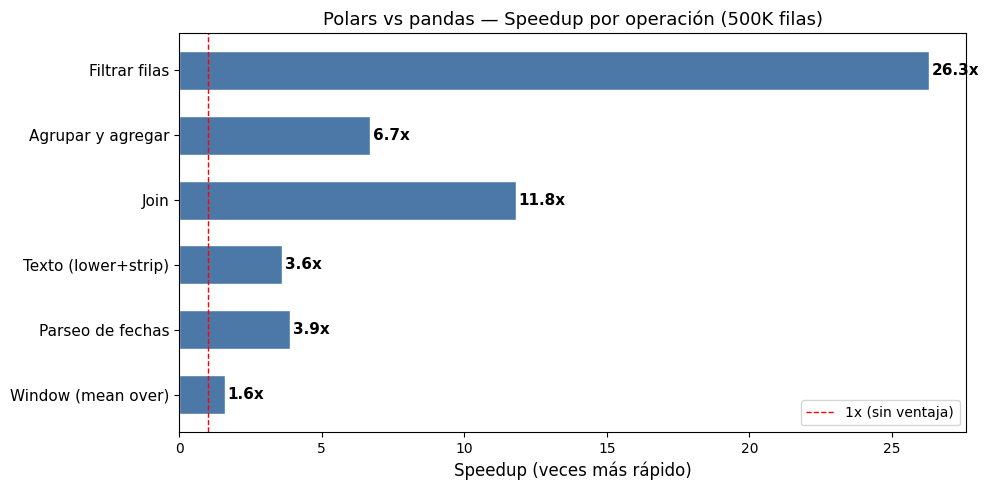

In [32]:
# --- Gráfica de speedup ---
import matplotlib.pyplot as plt

fig, ax = plt.subplots(figsize=(10, 5))

# Barras horizontales para mejor legibilidad de nombres
y_pos = range(len(operaciones))
bars = ax.barh(y_pos, speedups, color="#4c78a8", edgecolor="white", height=0.6)

# Línea de referencia en 1x (sin ventaja)
ax.axvline(x=1, color="red", linestyle="--", linewidth=1, label="1x (sin ventaja)")

# Etiquetas en cada barra
for bar, sp in zip(bars, speedups):
    ax.text(bar.get_width() + 0.1, bar.get_y() + bar.get_height() / 2,
            f"{sp}x", va="center", fontsize=11, fontweight="bold")

ax.set_yticks(y_pos)
ax.set_yticklabels(operaciones, fontsize=11)
ax.set_xlabel("Speedup (veces más rápido)", fontsize=12)
ax.set_title("Polars vs pandas — Speedup por operación (500K filas)", fontsize=13)
ax.legend(loc="lower right")
ax.invert_yaxis()  # primera operación arriba

plt.tight_layout()

# Guardar imagen
output_path = "../images/comparacion_pandas_polars.png"
fig.savefig(output_path, dpi=150, bbox_inches="tight")
print(f"Gráfica guardada en {output_path}")

plt.show()

---
## Conclusiones

1. **API:** Polars es más explícita y consistente. Cada operación tiene un método
   claro (`select`, `filter`, `with_columns`, `group_by`, `join`) en lugar de la
   ambigüedad de `df[x]` en pandas.

2. **Rendimiento:** Polars es consistentemente más rápido, especialmente en:
   - Operaciones de texto (Arrow Utf8 vs Python object)
   - Parseo de fechas (formato explícito vs adivinación)
   - Window functions (paralelización nativa)

3. **Tipos:** Polars preserva los tipos incluso con nulls. pandas convierte
   `int → float` al introducir un solo `NaN`, causando bugs sutiles.

4. **Inmutabilidad:** En Polars no existe `SettingWithCopyWarning` porque todo
   es inmutable por diseño.

> **Referencia:** Sección 17.5 en `05_polars_vs_pandas.md` contiene la tabla comparativa completa y las explicaciones teóricas de cada diferencia.